# TemporalVAE demo notebook with Xiang19 dataset (<A developmental landscape of 3D-cultured human pre-gastrulation embryos>)

## preprocess the orginal data of Xiang19(GEO:GSE136447)

### set up work space

In [1]:
# -*-coding:utf-8 -*-
import sys
print(f"python version: {sys.version}; {sys.executable}")
import os
print(os.getcwd())
os.chdir("/mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE")
sys.path.append(os.getcwd())

python version: 3.10.9 | packaged by conda-forge | (main, Feb  2 2023, 20:20:04) [GCC 11.3.0]; /mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/bin/python
/mnt/yijun


### import necessary function

In [2]:
from TemporalVAE.utils.utils_project import *
from TemporalVAE.utils.utils_project import *
from collections import Counter
import os
import yaml
import argparse
import anndata as ad
import numpy as np
import pandas as pd
import logging
from TemporalVAE.utils import LogHelper
import torch

### Set necessary parameters for dataset preprocessing and model training

In [3]:
result_save_path="results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/"
data_golbal_path = "data/"
data_path="/human_embryo_preimplantation/integration_8dataset/"
min_gene_num=50
min_cell_num=50
train_epoch_num=50
batch_size=100000
time_standard_type="embryoneg5to5"
vae_param_file="supervise_vae_regressionclfdecoder_mouse_stereo"
os.getcwd()
vae_param_file

'supervise_vae_regressionclfdecoder_mouse_stereo'

 ### import vae model parameters from yaml file

In [4]:
with open(f"vae_model_configs/{vae_param_file}.yaml", 'r') as file:
    try:
        config = yaml.safe_load(file)
    except yaml.YAMLError as exc:
        print(exc)

### set logger and parameters, creat result save path and folder

In [5]:
latent_dim = config['model_params']['latent_dim']
_path = '{}/{}/'.format(result_save_path, data_path)
if not os.path.exists(_path):
    os.makedirs(_path)
_path

'results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713///human_embryo_preimplantation/integration_8dataset//'

In [6]:
logger_file = '{}/{}_dim{}_time{}_epoch{}_minGeneNum{}.log'.format(_path, vae_param_file, latent_dim,
                                                                   time_standard_type, train_epoch_num,
                                                                   min_gene_num)
LogHelper.setup(log_path=logger_file, level='INFO')
_logger = logging.getLogger(__name__)
_logger.info("Finished setting up the logger at: {}.".format(logger_file))
_logger.info("Train on dataset: {}.".format(data_golbal_path + data_path))

_logger.info("load vae model parameters from file: {}".format(vae_param_file + ".yaml"))

2025-07-13 09:34:46,796 INFO - __main__ - Finished setting up the logger at: results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713///human_embryo_preimplantation/integration_8dataset///supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50.log. 
2025-07-13 09:34:46,979 INFO - __main__ - Train on dataset: data//human_embryo_preimplantation/integration_8dataset/. 
2025-07-13 09:34:46,980 INFO - __main__ - load vae model parameters from file: supervise_vae_regressionclfdecoder_mouse_stereo.yaml 


### Load Xiang data from human integration dataset, which could be downloaded from `https://zenodo.org/records/15366361`

In [7]:
# filter xiang data from integrated dataset
temp_adata = ad.read_h5ad(f"data/{data_path}/rawCount_Z_C_Xiao_M_P_Liu_Tyser_Xiang.h5ad")
temp_adata

AnnData object with n_obs × n_vars = 25003 × 1692
    obs: 'time', 'day', 'dataset_label', 'donor', 'cell_type', 'title', 'species', 'n_genes'
    var: 'n_cells'

In [8]:
temp_adata = temp_adata[temp_adata.obs['dataset_label'] == "Xiang"]
temp_adata

View of AnnData object with n_obs × n_vars = 555 × 1692
    obs: 'time', 'day', 'dataset_label', 'donor', 'cell_type', 'title', 'species', 'n_genes'
    var: 'n_cells'

In [9]:
temp_adata_raw_count = pd.DataFrame(data=temp_adata.X.T,
                                    columns=temp_adata.obs.index,
                                    index=temp_adata.var_names)
temp_adata_raw_count

,D6N1B23,D6N1B6,D6N1S1,D6N1S15,D6N1S19,D6N1S3,D6N1S33,D6N1S34,D6N1S35,D6N1S39,...,D14_2S1,D14_3B5,D14_3B6,D14_3S10,D14_3S15,D14_3S16,D14_3S9,D14_2S2,D14_2B1,D14_2B3
A1CF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M,0.0,0.0,302.0,0.0,0.0,0.0,387.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0
AADAT,446.0,1099.0,0.0,925.0,0.0,868.0,0.0,5.0,0.0,0.0,...,842.0,3535.0,11491.0,0.0,6762.0,333.0,5.0,815.0,1964.0,1150.0
AAMDC,18.0,6.0,0.0,31.0,17.0,79.0,0.0,0.0,0.0,11.0,...,13.0,48.0,75.0,19.0,0.0,0.0,0.0,0.0,120.0,64.0
ABAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,497.0,0.0,0.0,...,0.0,0.0,0.0,7151.0,0.0,0.0,0.0,0.0,0.0,544.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZP3,155.0,239.0,0.0,0.0,32.0,0.0,0.0,0.0,95.0,230.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ZSCAN10,11.0,438.0,0.0,12614.0,6.0,1299.0,11239.0,12338.0,2.0,4900.0,...,0.0,0.0,0.0,20407.0,17563.0,27.0,0.0,0.0,0.0,0.0
ZSCAN4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0
ZSCAN5B,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
temp_adata_raw_count.to_csv(f"data/{data_path}/Xiang_rawCount.csv", sep="\t")
temp_adata.obs.to_csv(f"data/{data_path}/Xiang_cellAnnotation.csv", sep="\t")
sc_data_file_csv = f"{data_path}/Xiang_rawCount.csv"
cell_info_file_csv = f"{data_path}/Xiang_cellAnnotation.csv"

### Preprocess data, with hvg gene from preprocess_data_mouse_embryonic_development.py

In [11]:
sc_expression_df, cell_time = preprocessData_and_dropout_some_donor_or_gene(data_golbal_path,
                                                                                sc_data_file_csv,
                                                                                cell_info_file_csv,
                                                                                # donor_attr=donor_attr, drop_out_donor=drop_out_donor,
                                                                                min_cell_num=min_cell_num,
                                                                                min_gene_num=min_gene_num,
                                                                                data_raw_count_bool=True)  # 2024-04-20 15:38:58
special_path_str = ""

2025-07-13 09:34:48,932 INFO - TemporalVAE.utils.utils_project - the original sc expression anndata should be gene as row, cell as column 
2025-07-13 09:34:48,932 INFO - TemporalVAE.utils.utils_project - input data is .csv file, where gene as row, cell as column. 
2025-07-13 09:34:49,076 INFO - TemporalVAE.utils.utils_project - read the original sc expression anndata with shape (gene, cell): (1692, 555) 
2025-07-13 09:34:49,080 INFO - TemporalVAE.utils.utils_project - cell annotation includes Index(['time', 'day', 'dataset_label', 'donor', 'cell_type', 'title',
       'species', 'n_genes'],
      dtype='object') 
2025-07-13 09:34:49,080 INFO - TemporalVAE.utils.utils_project - Import data, cell number: 555, gene number: 1692 
2025-07-13 09:34:49,092 INFO - TemporalVAE.utils.utils_project - After drop gene threshold: 50, cell threshold: 50, remain adata shape: (555, 1188) 
2025-07-13 09:34:49,093 INFO - TemporalVAE.utils.utils_project - Drop cells with less than 50 gene expression, drop

normalized sample to 1000000.0
Input data is raw count, do the log1p().


In [12]:
sc_expression_df

,AADAT,AAMDC,ABAT,ABCC11,ABCC3,ABCC9,ABLIM1,ABLIM2,ACAT2,ACKR3,...,ZNF585B,ZNF649,ZNF703,ZNF750,ZNF835,ZNF836,ZP3,ZSCAN10,ZSCAN4,ZSWIM6
D6N1B23,0.803352,0.603420,-0.460936,-0.353707,-0.290316,-0.516165,-0.638925,-0.448838,0.245026,-0.647664,...,-0.995479,-1.032637,1.285974,1.196633,-0.439501,-0.840075,1.489011,-0.129851,-0.414599,-0.384630
D6N1B6,1.198257,0.175606,-0.460936,-0.353707,-0.290316,-0.516165,-0.638925,-0.448838,-1.002497,-0.647664,...,-0.022324,0.655709,0.319597,0.987185,-0.439501,-0.840075,1.811035,1.000046,-0.414599,-0.384630
D6N1S1,-1.158764,-0.760792,-0.460936,-0.353707,-0.290316,-0.516165,-0.638925,-0.448838,1.090450,1.679591,...,2.191792,-0.003134,-1.260395,-1.009398,-0.439501,-0.180040,-0.754942,-0.729381,-0.414599,4.091528
D6N1S15,1.256729,1.186619,-0.460936,-0.353707,-0.290316,-0.516165,-0.638925,-0.448838,0.445563,-0.647664,...,-0.995479,1.426095,-0.515178,-1.009398,-0.439501,-0.840075,-0.754942,2.110463,-0.414599,-0.384630
D6N1S19,-1.158764,0.775663,-0.460936,-0.353707,-0.290316,0.597442,-0.638925,-0.448838,1.281792,-0.647664,...,-0.995479,1.270356,0.891959,-0.448862,-0.439501,-0.840075,0.909654,-0.185220,-0.414599,-0.384630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D14_3S16,0.448343,-0.760792,-0.460936,-0.353707,-0.290316,-0.516165,0.902968,-0.448838,-0.287500,-0.647664,...,-0.190675,-1.032637,-1.260395,-1.009398,2.054579,1.955389,-0.754942,-0.083038,-0.414599,-0.384630
D14_3S9,-0.849417,-0.760792,-0.460936,-0.353707,2.966463,-0.516165,-0.638925,-0.448838,1.191676,-0.647664,...,-0.682381,-1.032637,-1.260395,-1.009398,-0.439501,-0.840075,-0.754942,-0.729381,-0.414599,-0.384630
D14_2S2,0.767057,-0.760792,-0.460936,-0.353707,-0.290316,-0.516165,-0.638925,0.036878,-0.687337,-0.647664,...,0.864986,-0.438790,0.477721,-1.009398,0.079347,0.574267,-0.754942,-0.729381,0.108745,-0.384630
D14_2B1,0.659232,0.605823,-0.460936,-0.353707,-0.290316,-0.516165,-0.638925,-0.448838,-1.425905,-0.647664,...,-0.441060,-1.032637,0.407828,-0.380989,-0.439501,-0.840075,-0.754942,-0.729381,-0.414599,-0.384630


In [13]:
cell_time

,time,day,dataset_label,donor,cell_type,title,species,n_genes
D6N1B23,6.0,D6_xiang19,Xiang,D6_xiang19,Inner cell mass,Embryo_D6N1B23,human,520
D6N1B6,6.0,D6_xiang19,Xiang,D6_xiang19,Inner cell mass,Embryo_D6N1B6,human,622
D6N1S1,6.0,D6_xiang19,Xiang,D6_xiang19,Epiblast,Embryo_D6N1S1,human,482
D6N1S15,6.0,D6_xiang19,Xiang,D6_xiang19,Epiblast,Embryo_D6N1S15,human,525
D6N1S19,6.0,D6_xiang19,Xiang,D6_xiang19,Inner cell mass,Embryo_D6N1S19,human,494
...,...,...,...,...,...,...,...,...
D14_3S16,14.0,D14_xiang19,Xiang,D14_xiang19,Epiblast,Embryo_D14_3S16,human,537
D14_3S9,14.0,D14_xiang19,Xiang,D14_xiang19,Cytotrophoblast,Embryo_D14_3S9,human,477
D14_2S2,14.0,D14_xiang19,Xiang,D14_xiang19,Syncytiotrophoblast,Embryo_D14_2S2,human,688
D14_2B1,14.0,D14_xiang19,Xiang,D14_xiang19,Extravillous Cytotrophoblast,Embryo_D14_2B1,human,687


### Set donor list and dictionary

In [14]:
donor_list = np.unique(cell_time["day"])
donor_list = sorted(donor_list, key=Embryodonor_resort_key)
donor_dic = dict()
for i in range(len(donor_list)):
    donor_dic[donor_list[i]] = i
batch_dic = donor_dic.copy()
_logger.info("Consider donor as batch effect, donor use label: {}".format(donor_dic))
_logger.info("For each donor (donor_id, cell_num):{} ".format(Counter(cell_time["day"])))
save_file_name = f"{_logger.root.handlers[0].baseFilename.replace('.log', '')}/"

2025-07-13 09:34:51,809 INFO - __main__ - Consider donor as batch effect, donor use label: {'D10_xiang19': 0, 'D12_xiang19': 1, 'D14_xiang19': 2, 'D6_xiang19': 3, 'D7_xiang19': 4, 'D8_xiang19': 5, 'D9_xiang19': 6} 
2025-07-13 09:34:51,810 INFO - __main__ - For each donor (donor_id, cell_num):Counter({'D14_xiang19': 135, 'D12_xiang19': 88, 'D10_xiang19': 77, 'D9_xiang19': 68, 'D7_xiang19': 65, 'D6_xiang19': 63, 'D8_xiang19': 59})  


## 1. If you want to do train on all donors and check the umap of latent space.

/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/lightning_fabric/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
2025-07-13 09:34:53,155 INFO - torch.distributed.nn.jit.instantiator - Created a temporary directory at /mnt/yijun/nfs_share/yijun_tmp/tmppprs300s 
2025-07-13 09:34:53,157 INFO - torch.distributed.nn.jit.instantiator - Writing /mnt/yijun/nfs_share/yijun_tmp/tmppprs300s/_remote_module_non_scriptable.py 
2025-07-13 09:34:53,290 INFO - TemporalVAE.utils.utils_project - Set x_sc_train data with shape (gene, cells): torch.Size([1188, 555]) 
2025-07-13 09:34:53,296 INFO - TemporalVAE.utils.utils_project - label dictionary: {600: -5.0, 700: -3.75, 800: -2.5, 900: -1.25, 1000: 0.0, 120

Free Memory Percentage: 66.28%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 39.369GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 39.369GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 25.221GB.

[INFO] more than 5% free memory, Auto select GPU device 2,- memory free: 39.369GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: PossibleUserWarning: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
  rank_zero_warn(
2025-07-13 09:34:53,640 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 09:34:54,466 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
2025-07-13 09:34:54,470 INFO - pytorch_lightning.callbacks.model_summary - 
  | Name  | Type                                                         | Params
--------------------------------

Training: 0it [00:00, ?it/s]

Epoch train loss: {'train_loss_step': tensor(13.7450, device='cuda:2'), 'train_Reconstruction_loss_step': tensor(1.3866, device='cuda:2'), 'train_KLD_step': tensor(-6.7930, device='cuda:2'), 'train_clf_loss_step': tensor(12.3566, device='cuda:2'), 'train_loss_epoch': tensor(13.7450, device='cuda:2'), 'train_Reconstruction_loss_epoch': tensor(1.3866, device='cuda:2'), 'train_KLD_epoch': tensor(-6.7930, device='cuda:2'), 'train_clf_loss_epoch': tensor(12.3566, device='cuda:2')}
Epoch train loss: {'train_loss_step': tensor(13.4233, device='cuda:2'), 'train_Reconstruction_loss_step': tensor(1.3345, device='cuda:2'), 'train_KLD_step': tensor(-7.6028, device='cuda:2'), 'train_clf_loss_step': tensor(12.0869, device='cuda:2'), 'train_loss_epoch': tensor(13.4233, device='cuda:2'), 'train_Reconstruction_loss_epoch': tensor(1.3345, device='cuda:2'), 'train_KLD_epoch': tensor(-7.6028, device='cuda:2'), 'train_clf_loss_epoch': tensor(12.0869, device='cuda:2')}
Epoch train loss: {'train_loss_step': 

2025-07-13 09:35:20,706 INFO - pytorch_lightning.utilities.rank_zero - `Trainer.fit` stopped: `max_epochs=50` reached. 
2025-07-13 09:35:20,757 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 09:35:20,768 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, predict_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which 

Predicting: 0it [00:00, ?it/s]

2025-07-13 09:35:20,826 INFO - TemporalVAE.utils.utils_project - Plot training loss line for check. 
2025-07-13 09:35:20,866 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1752417294.GPU2.3120721.0 
2025-07-13 09:35:20,867 INFO - TemporalVAE.utils.utils_project - All tags in logger: ['lr-Adam', 'train_loss_step', 'train_Reconstruction_loss_step', 'train_KLD_step', 'train_clf_loss_step', 'epoch', 'train_loss_epoch', 'train_Reconstruction_loss_epoch', 'train_KLD_epoch', 'train_clf_loss_epoch'] 
2025-07-13 09:35:20,867 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 09:35:20,885 INFO - tensorboard - No path fo

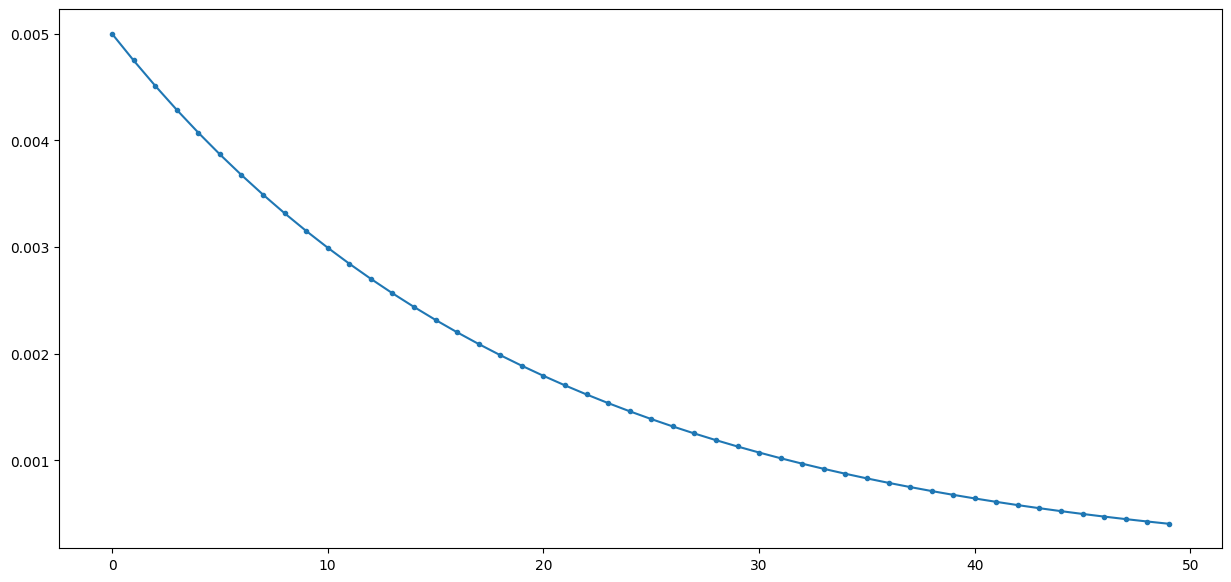

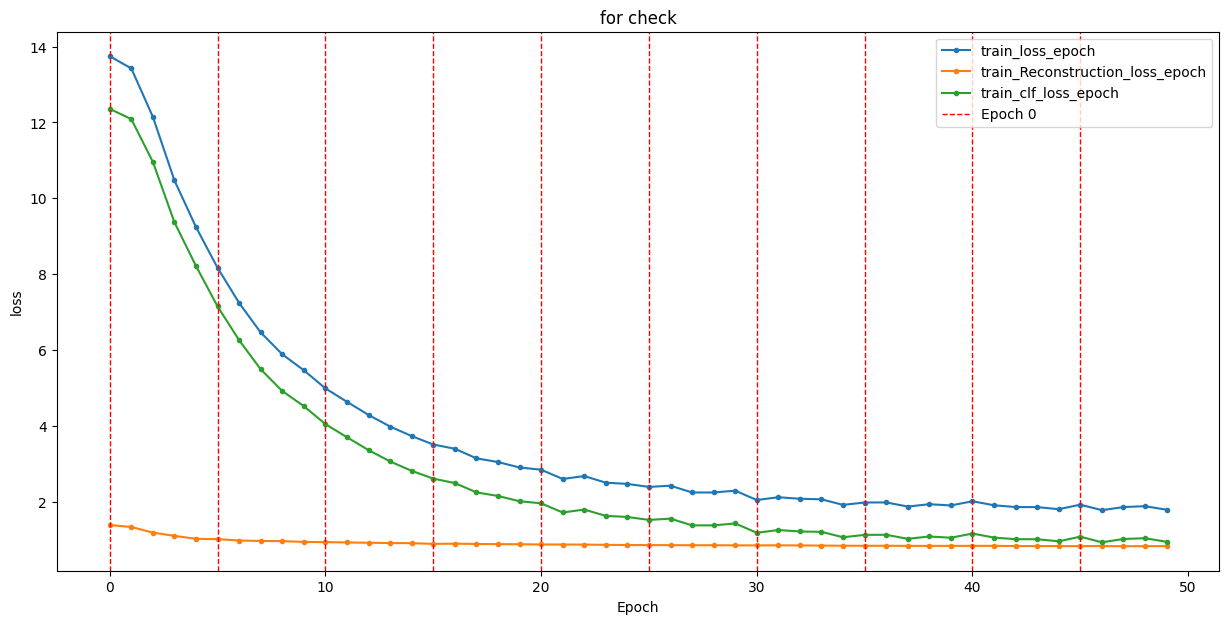

2025-07-13 09:35:21,357 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 09:35:21,376 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1752417294.GPU2.3120721.0 
2025-07-13 09:35:21,550 INFO - TemporalVAE.utils.utils_plot - Finish save images at: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/trainingLoss_train_Reco

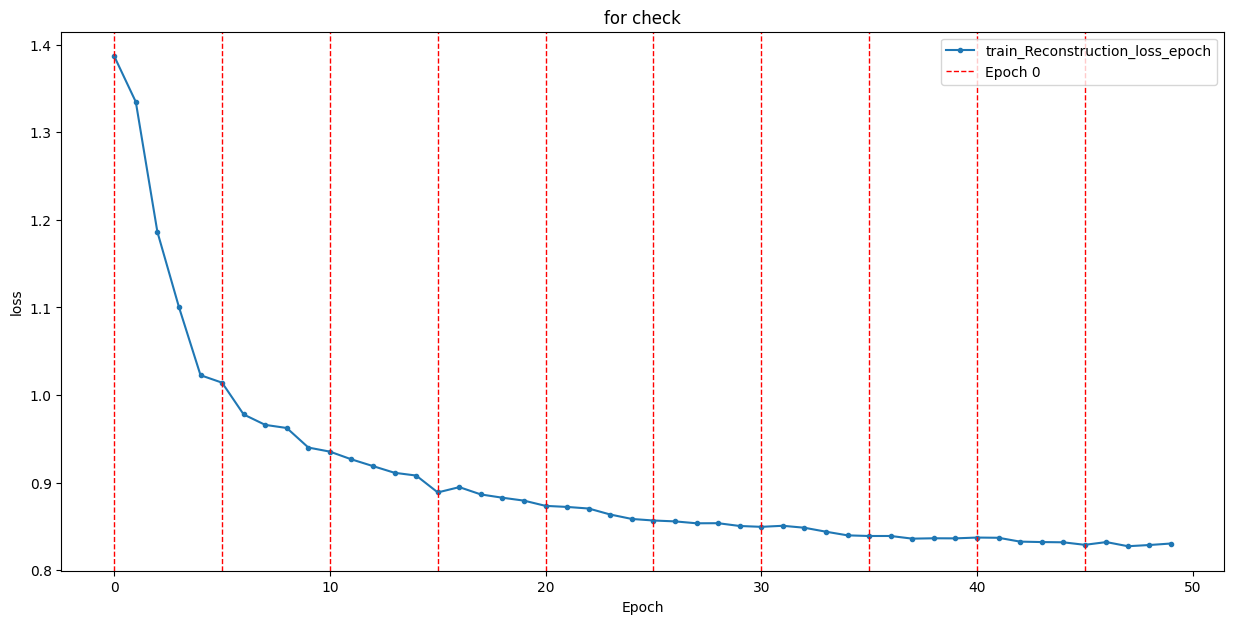

2025-07-13 09:35:21,685 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 09:35:21,704 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1752417294.GPU2.3120721.0 


<Figure size 1500x700 with 0 Axes>

In [15]:
sc_expression_train, y_time_nor_train, donor_index_train, runner, experiment, _m, train_clf_result, label_dic, total_result = onlyTrain_model(
    sc_expression_df, donor_dic,
    special_path_str,
    cell_time,
    time_standard_type, config, train_epoch_num,
     plot_latentSpaceUmap=False, plot_trainingLossLine=True, time_saved_asFloat=True, batch_dic=batch_dic, donor_str="day",
    batch_size=int(batch_size))  # 2023-10-24 17:44:31 batch as 10,000 due to overfit, batch size as 100,000 may be have different result

In [16]:
predict_donors_df = pd.DataFrame(train_clf_result, columns=["pseudotime"], index=cell_time.index)
predict_donors_df['predicted_time'] = predict_donors_df['pseudotime'].apply(denormalize, args=(min(label_dic.keys()) / 100, max(label_dic.keys()) / 100,
                                                                                               min(label_dic.values()), max(label_dic.values())))
predict_donors_df

,pseudotime,predicted_time
D6N1B23,-4.504539,6.396369
D6N1B6,-4.584133,6.332693
D6N1S1,-4.393116,6.485507
D6N1S15,-4.539454,6.368437
D6N1S19,-4.506180,6.395056
...,...,...
D14_3S16,4.806302,13.845042
D14_3S9,4.747910,13.798328
D14_2S2,4.726017,13.780814
D14_2B1,4.792021,13.833617


In [17]:
cell_time = pd.concat([cell_time, predict_donors_df], axis=1)
cell_time

,time,day,dataset_label,donor,cell_type,title,species,n_genes,pseudotime,predicted_time
D6N1B23,6.0,D6_xiang19,Xiang,D6_xiang19,Inner cell mass,Embryo_D6N1B23,human,520,-4.504539,6.396369
D6N1B6,6.0,D6_xiang19,Xiang,D6_xiang19,Inner cell mass,Embryo_D6N1B6,human,622,-4.584133,6.332693
D6N1S1,6.0,D6_xiang19,Xiang,D6_xiang19,Epiblast,Embryo_D6N1S1,human,482,-4.393116,6.485507
D6N1S15,6.0,D6_xiang19,Xiang,D6_xiang19,Epiblast,Embryo_D6N1S15,human,525,-4.539454,6.368437
D6N1S19,6.0,D6_xiang19,Xiang,D6_xiang19,Inner cell mass,Embryo_D6N1S19,human,494,-4.506180,6.395056
...,...,...,...,...,...,...,...,...,...,...
D14_3S16,14.0,D14_xiang19,Xiang,D14_xiang19,Epiblast,Embryo_D14_3S16,human,537,4.806302,13.845042
D14_3S9,14.0,D14_xiang19,Xiang,D14_xiang19,Cytotrophoblast,Embryo_D14_3S9,human,477,4.747910,13.798328
D14_2S2,14.0,D14_xiang19,Xiang,D14_xiang19,Syncytiotrophoblast,Embryo_D14_2S2,human,688,4.726017,13.780814
D14_2B1,14.0,D14_xiang19,Xiang,D14_xiang19,Extravillous Cytotrophoblast,Embryo_D14_2B1,human,687,4.792021,13.833617


In [18]:
plt_image_adata = ad.AnnData(X=total_result["mu"].cpu().numpy())
plt_image_adata.obs = cell_time[["time", "predicted_time", "dataset_label", "cell_type", "day"]]
plt_image_adata

AnnData object with n_obs × n_vars = 555 × 50
    obs: 'time', 'predicted_time', 'dataset_label', 'cell_type', 'day'

... storing 'dataset_label' as categorical
... storing 'cell_type' as categorical
... storing 'day' as categorical


latent mu save as /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50//n50_latent_mu.h5ad


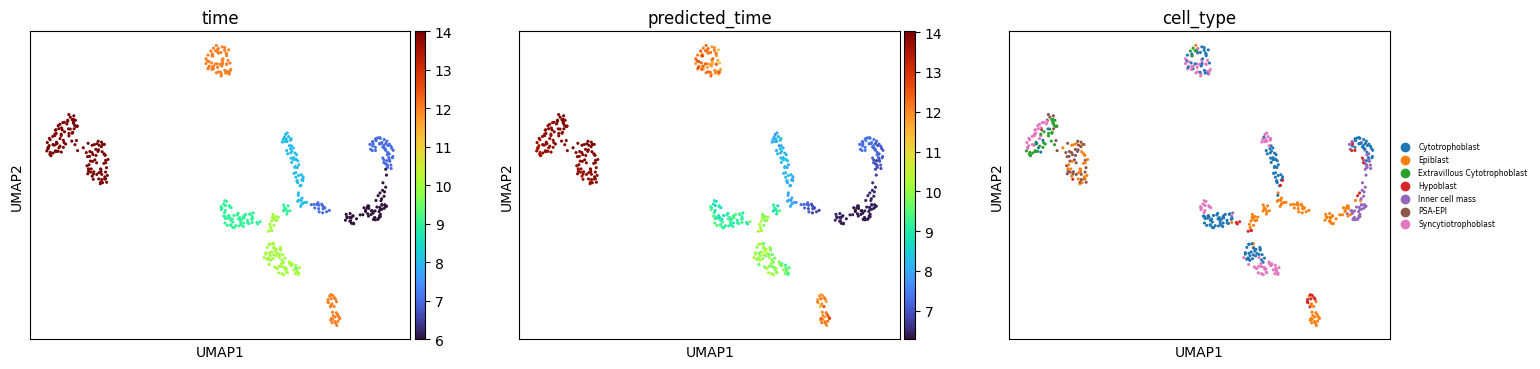

figure save as /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50//n50_latentSpace_umap_byScanpy.png


AnnData object with n_obs × n_vars = 555 × 50
    obs: 'time', 'predicted_time', 'dataset_label', 'cell_type', 'day'
    uns: 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'X_umap'
    obsp: 'distances', 'connectivities'

In [19]:
plt_umap_byScanpy(plt_image_adata.copy(),
                  ["time", "predicted_time", "cell_type"],
                  save_path=save_file_name, mode=None, figure_size=(5, 4),
                  color_map="turbo",
                  n_neighbors=80, n_pcs=10, special_file_name_str="n50_")

## If you want to do multiple loop calculations: test on one donor and train on other donors.

2025-07-13 09:35:31,773 INFO - __main__ - start task: k-fold test with ['D10_xiang19', 'D12_xiang19', 'D14_xiang19', 'D6_xiang19', 'D7_xiang19', 'D8_xiang19', 'D9_xiang19']. 
2025-07-13 09:35:32,006 INFO - TemporalVAE.utils.utils_project - the 1/7 fold train, use donor-D10_xiang19 as test set 
2025-07-13 09:35:32,014 INFO - TemporalVAE.utils.utils_project - Set x_sc_train data with shape (gene, cells): torch.Size([1188, 478]) 
2025-07-13 09:35:32,015 INFO - TemporalVAE.utils.utils_project - Set x_sc_test data with shape (gene, cells): torch.Size([1188, 77]) 
2025-07-13 09:35:32,044 INFO - TemporalVAE.utils.utils_project - label dictionary: {600: -5.0, 700: -3.75, 800: -2.5, 900: -1.25, 1200: 2.5, 1400: 5.0, 1000: 0.0} 
2025-07-13 09:35:32,045 INFO - TemporalVAE.utils.utils_project - Normalize train y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [ 600.  700.  800.  900. 1200. 1400.], shape: torch.Size([478]), 
detail: [-5.   -3.75 -2.5  -1.25  2.5   5.  ] 
2025-07-13

Free Memory Percentage: 66.93%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 38.861GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 39.369GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 25.221GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 39.369GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


2025-07-13 09:35:32,852 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
2025-07-13 09:35:32,855 INFO - pytorch_lightning.callbacks.model_summary - 
  | Name  | Type                                                         | Params
---------------------------------------------------------------------------------------
0 | model | SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial | 5.0 M 
---------------------------------------------------------------------------------------
5.0 M     Trainable params
0         Non-trainable params
5.0 M     Total params
19.840    Total estimated model params size (MB) 


Sanity Checking: 0it [00:00, ?it/s]

/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


...

2025-07-13 09:35:49,910 INFO - TemporalVAE.utils.utils_project - this epoch final, on test data:[{'test_loss_epoch': 2.997837543487549, 'test_Reconstruction_loss_epoch': 0.7405974864959717, 'test_KLD_epoch': -9.169099807739258, 'test_clf_loss_epoch': 2.2549476623535156}] 
2025-07-13 09:35:49,911 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 09:35:49,916 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloade

Predicting: 0it [00:00, ?it/s]

2025-07-13 09:35:49,959 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 09:35:49,966 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2025-07-13 09:35:50,021 INFO - TemporalVAE.utils.utils_project - The Array does not contain NaN values 
2025-07-13 09:35:50,021 INFO - TemporalVAE.utils.utils_project - predicted time of test donor is continuous. 
2025-07-13 09:35:50,022 INFO - TemporalVAE.utils.utils_project - Plot training loss line for check. 
2025-07-13 09:35:50,048 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D10_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417332.GPU2.3120721.1 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_m

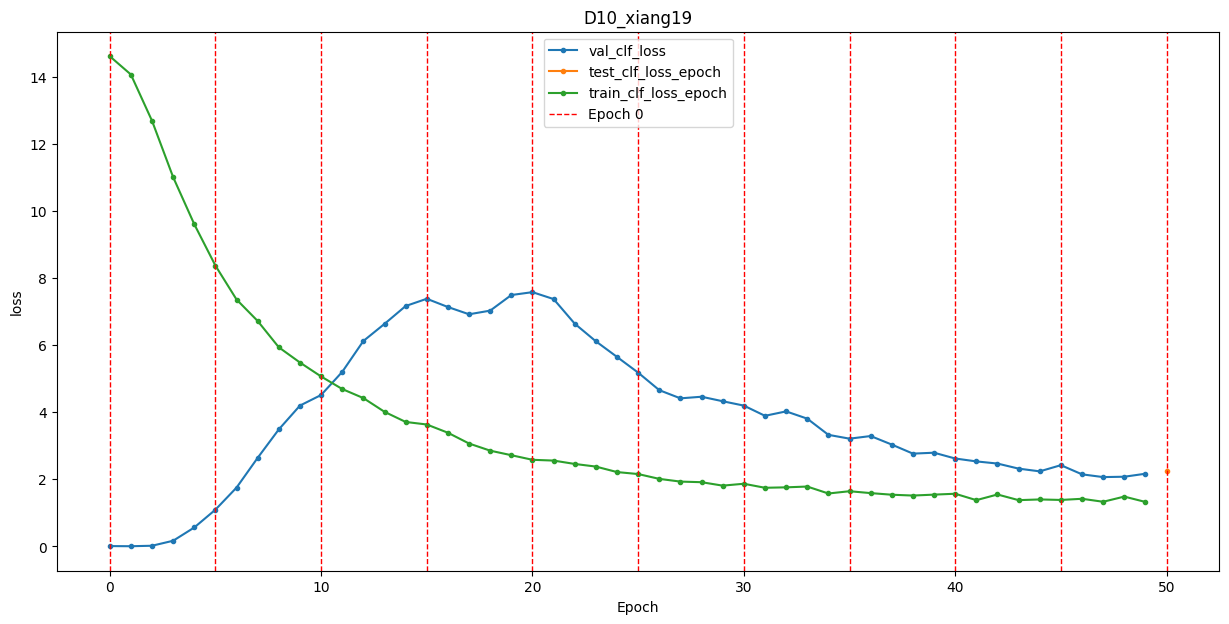

2025-07-13 09:35:50,419 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 09:35:50,452 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D10_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417332.GPU2.3120721.1 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D10_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417349.GPU2.3120721.2 
2025-07-13 09:35:50,454 INFO - tensorboard

Free Memory Percentage: 66.77%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 38.861GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 38.861GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 25.221GB.

[INFO] more than 5% free memory, Auto select GPU device 2,- memory free: 38.861GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


Sanity Checking: 0it [00:00, ?it/s]

/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

...

Predicting: 0it [00:00, ?it/s]

2025-07-13 09:36:08,470 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 09:36:08,477 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2025-07-13 09:36:08,514 INFO - TemporalVAE.utils.utils_project - The Array does not contain NaN values 
2025-07-13 09:36:08,515 INFO - TemporalVAE.utils.utils_project - predicted time of test donor is continuous. 
2025-07-13 09:36:08,516 INFO - TemporalVAE.utils.utils_project - Plot training loss line for check. 
2025-07-13 09:36:08,541 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D12_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417350.GPU2.3120721.3 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_m

<Figure size 1500x700 with 0 Axes>

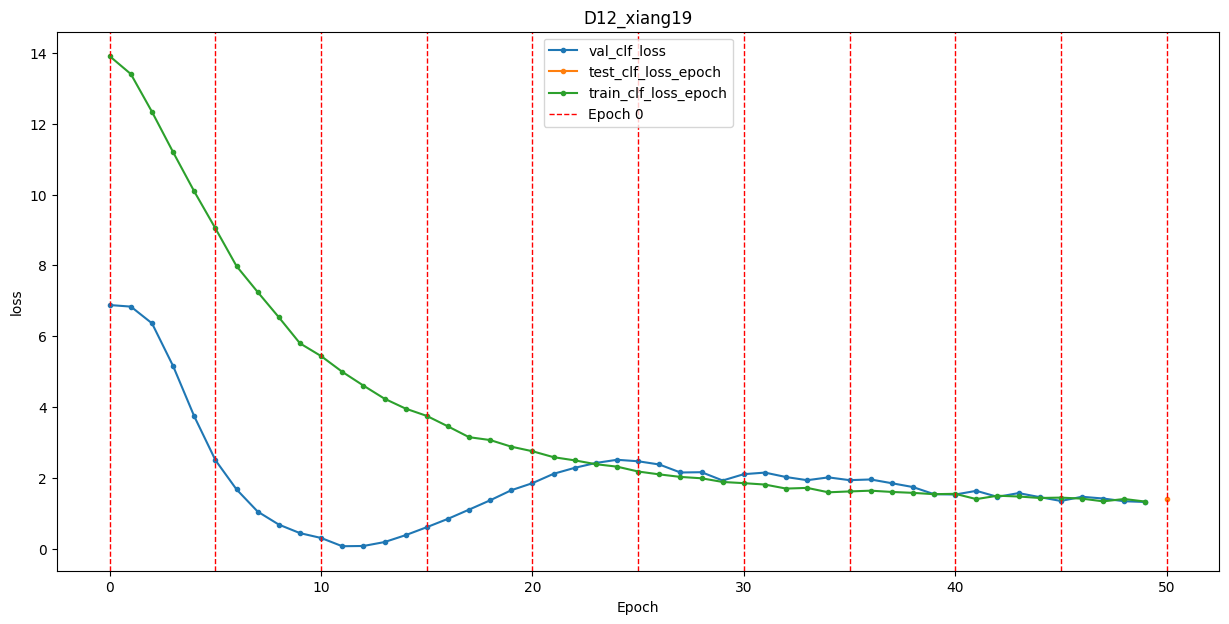

2025-07-13 09:36:08,914 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 09:36:08,938 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D12_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417350.GPU2.3120721.3 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D12_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417368.GPU2.3120721.4 
2025-07-13 09:36:08,940 INFO - tensorboard

Free Memory Percentage: 66.77%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 38.861GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 38.865GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 25.221GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 38.865GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


Sanity Checking: 0it [00:00, ?it/s]

/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

...

Predicting: 0it [00:00, ?it/s]

2025-07-13 09:36:33,251 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 09:36:33,258 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2025-07-13 09:36:33,300 INFO - TemporalVAE.utils.utils_project - The Array does not contain NaN values 
2025-07-13 09:36:33,300 INFO - TemporalVAE.utils.utils_project - predicted time of test donor is continuous. 
2025-07-13 09:36:33,301 INFO - TemporalVAE.utils.utils_project - Plot training loss line for check. 
2025-07-13 09:36:33,333 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D14_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417369.GPU2.3120721.5 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_m

<Figure size 1500x700 with 0 Axes>

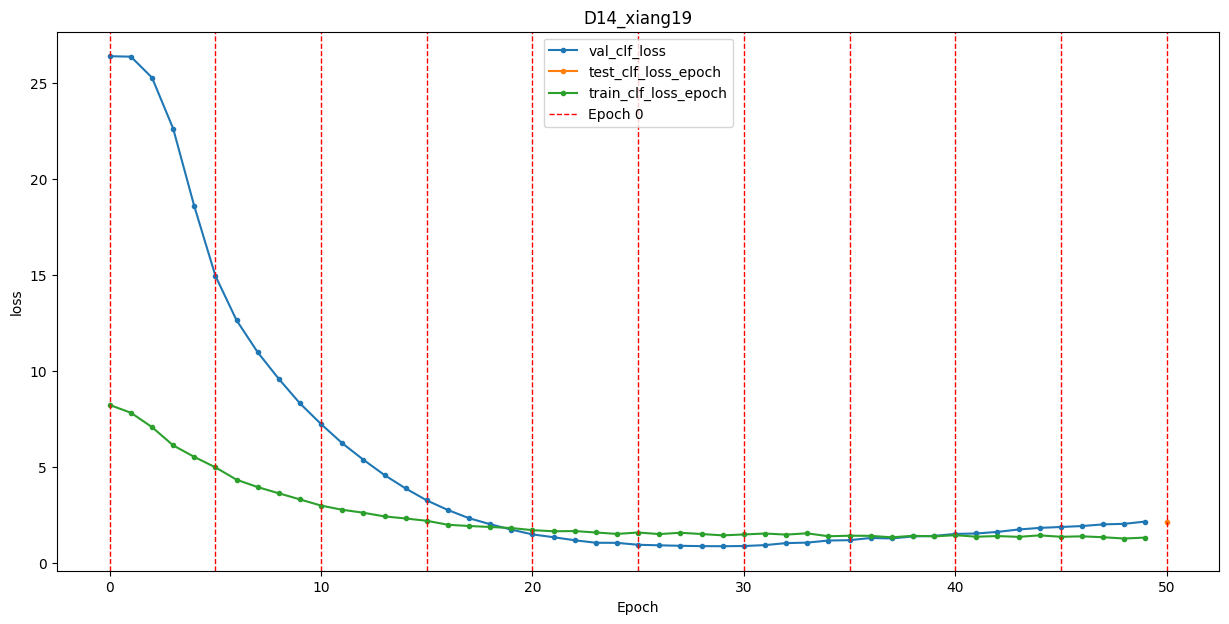

2025-07-13 09:36:33,698 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 09:36:33,723 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D14_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417369.GPU2.3120721.5 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D14_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417393.GPU2.3120721.6 
2025-07-13 09:36:33,724 INFO - tensorboard

Free Memory Percentage: 66.78%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 38.861GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 38.861GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 25.221GB.

[INFO] more than 5% free memory, Auto select GPU device 2,- memory free: 38.861GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


Sanity Checking: 0it [00:00, ?it/s]

/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

...

Predicting: 0it [00:00, ?it/s]

2025-07-13 09:36:57,802 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 09:36:57,808 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2025-07-13 09:36:57,851 INFO - TemporalVAE.utils.utils_project - The Array does not contain NaN values 
2025-07-13 09:36:57,851 INFO - TemporalVAE.utils.utils_project - predicted time of test donor is continuous. 
2025-07-13 09:36:57,852 INFO - TemporalVAE.utils.utils_project - Plot training loss line for check. 
2025-07-13 09:36:57,878 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D6_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417394.GPU2.3120721.7 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mo

<Figure size 1500x700 with 0 Axes>

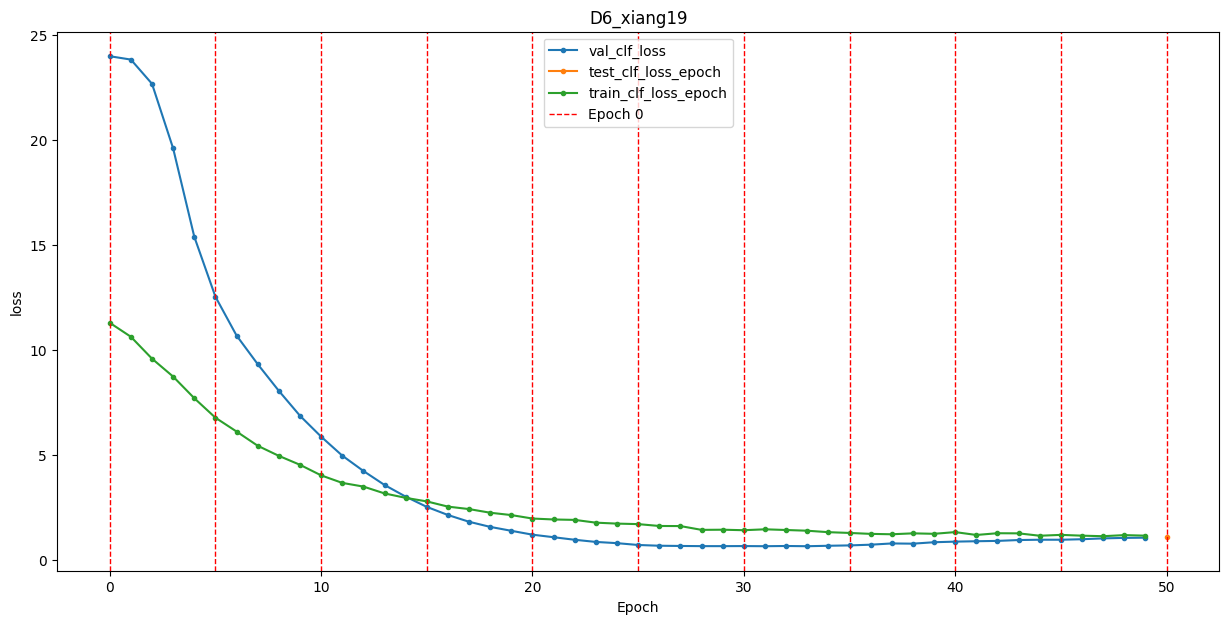

2025-07-13 09:36:58,241 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 09:36:58,265 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D6_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417394.GPU2.3120721.7 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D6_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417417.GPU2.3120721.8 
2025-07-13 09:36:58,267 INFO - tensorboard -

Free Memory Percentage: 66.78%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 38.859GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 38.865GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 25.221GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 38.865GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


Sanity Checking: 0it [00:00, ?it/s]

/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

...

Predicting: 0it [00:00, ?it/s]

2025-07-13 09:37:19,336 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 09:37:19,343 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2025-07-13 09:37:19,386 INFO - TemporalVAE.utils.utils_project - The Array does not contain NaN values 
2025-07-13 09:37:19,387 INFO - TemporalVAE.utils.utils_project - predicted time of test donor is continuous. 
2025-07-13 09:37:19,388 INFO - TemporalVAE.utils.utils_project - Plot training loss line for check. 
2025-07-13 09:37:19,413 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D7_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417418.GPU2.3120721.9 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mo

<Figure size 1500x700 with 0 Axes>

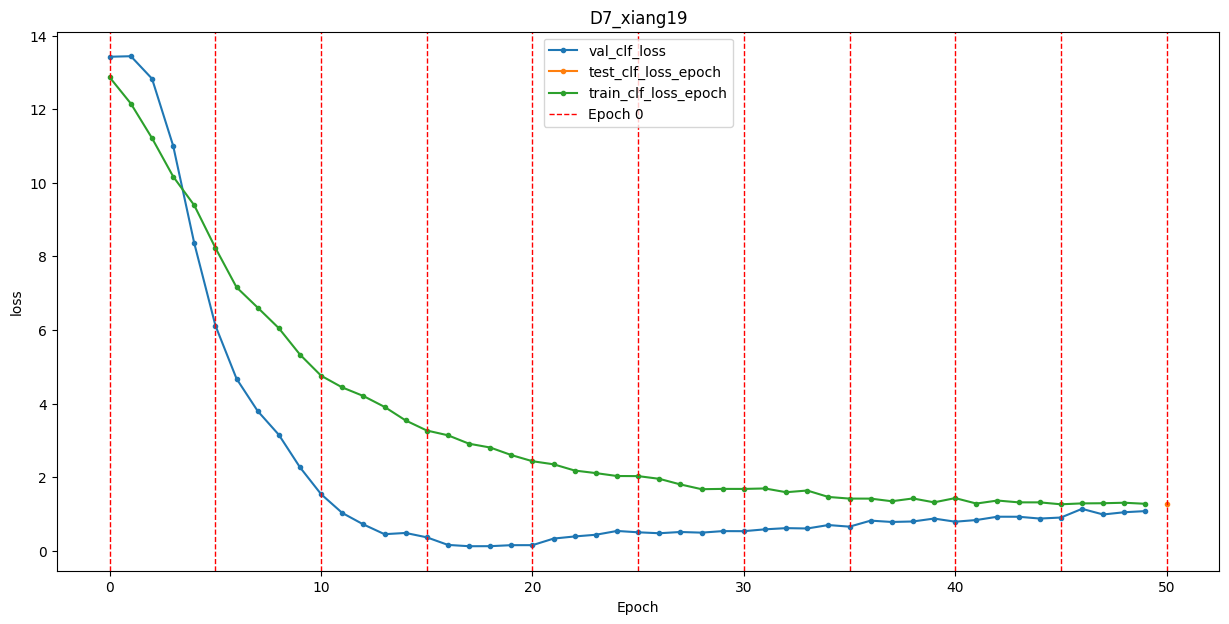

2025-07-13 09:37:19,790 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 09:37:19,815 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D7_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417418.GPU2.3120721.9 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D7_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417439.GPU2.3120721.10 
2025-07-13 09:37:19,817 INFO - tensorboard 

Free Memory Percentage: 66.77%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 38.861GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 38.863GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 25.221GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 38.863GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


Sanity Checking: 0it [00:00, ?it/s]

/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

...

Predicting: 0it [00:00, ?it/s]

2025-07-13 09:37:36,804 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 09:37:36,810 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2025-07-13 09:37:36,847 INFO - TemporalVAE.utils.utils_project - The Array does not contain NaN values 
2025-07-13 09:37:36,848 INFO - TemporalVAE.utils.utils_project - predicted time of test donor is continuous. 
2025-07-13 09:37:36,848 INFO - TemporalVAE.utils.utils_project - Plot training loss line for check. 
2025-07-13 09:37:36,873 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D8_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417440.GPU2.3120721.11 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_m

<Figure size 1500x700 with 0 Axes>

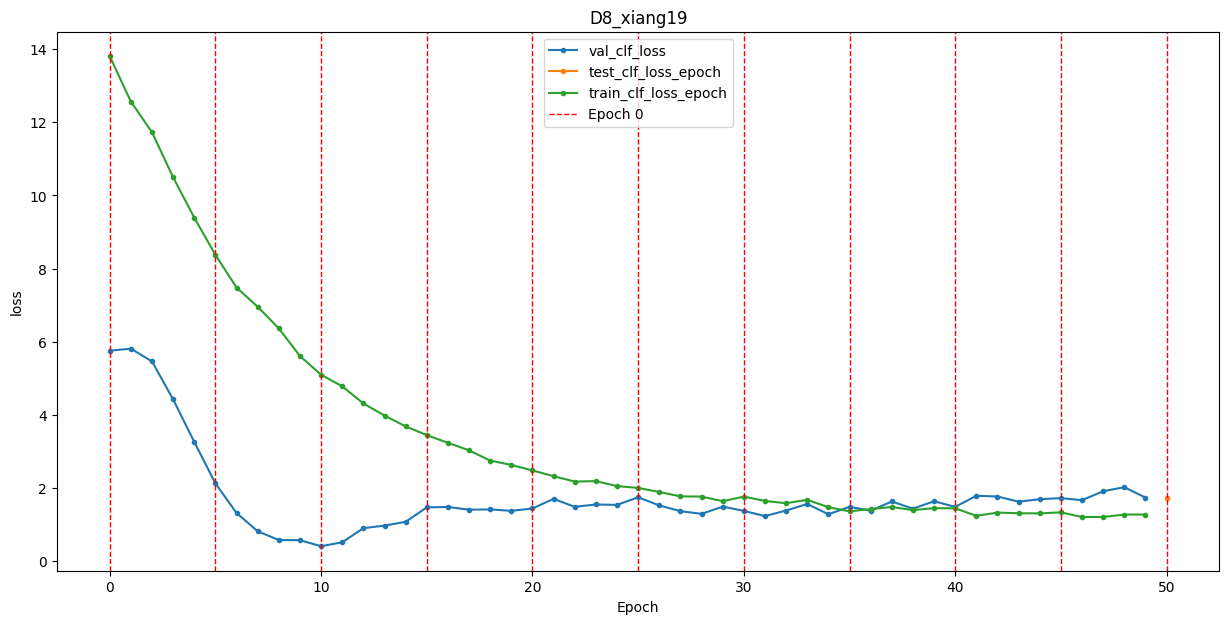

2025-07-13 09:37:37,241 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 09:37:37,266 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D8_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417440.GPU2.3120721.11 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D8_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417456.GPU2.3120721.12 
2025-07-13 09:37:37,267 INFO - tensorboard

Free Memory Percentage: 66.78%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 38.861GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 38.861GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 25.221GB.

[INFO] more than 5% free memory, Auto select GPU device 2,- memory free: 38.861GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


Sanity Checking: 0it [00:00, ?it/s]

/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

...

Predicting: 0it [00:00, ?it/s]

2025-07-13 09:37:57,276 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 09:37:57,283 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2025-07-13 09:37:57,333 INFO - TemporalVAE.utils.utils_project - The Array does not contain NaN values 
2025-07-13 09:37:57,333 INFO - TemporalVAE.utils.utils_project - predicted time of test donor is continuous. 
2025-07-13 09:37:57,335 INFO - TemporalVAE.utils.utils_project - Plot training loss line for check. 
2025-07-13 09:37:57,360 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D9_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417457.GPU2.3120721.13 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_m

<Figure size 1500x700 with 0 Axes>

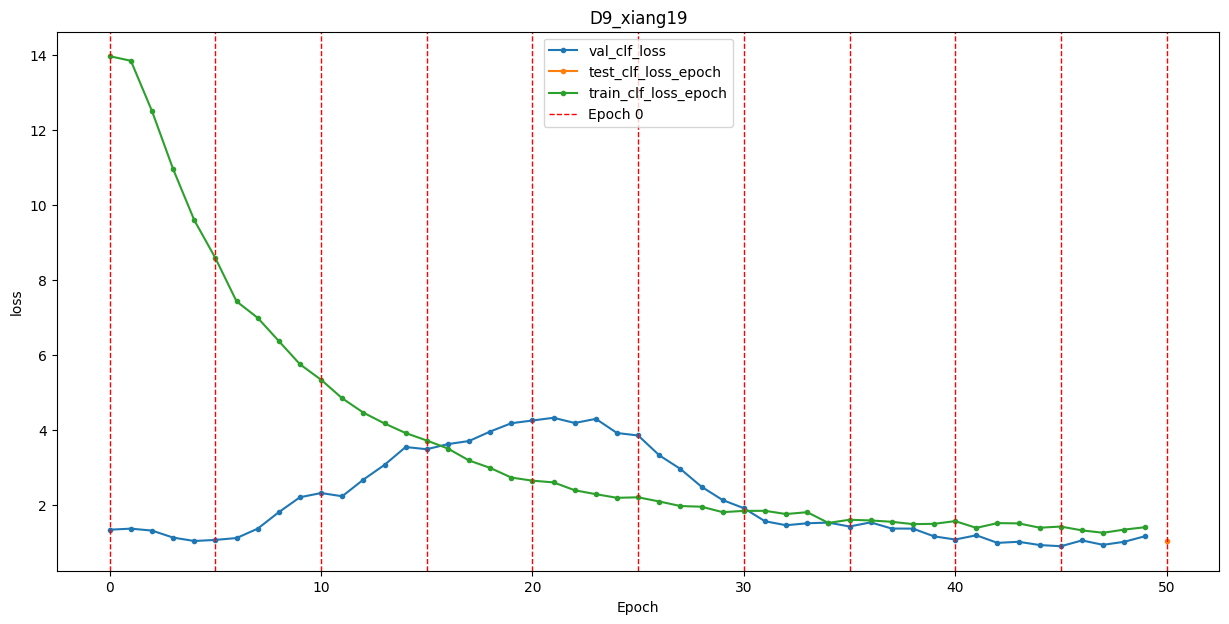

2025-07-13 09:37:57,731 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 09:37:57,755 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D9_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417457.GPU2.3120721.13 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/D9_xiang19/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752417477.GPU2.3120721.14 
2025-07-13 09:37:57,757 INFO - tensorboard

=== data correlation: 
Spearman correlation=0.91899, p-value=0.00000; 
Pearson correlation=0.93870, p-value=0.00000; 
Kendall correlation=0.77485, p-value=0.00000; 
R-squared=0.82542.


<Figure size 1500x700 with 0 Axes>

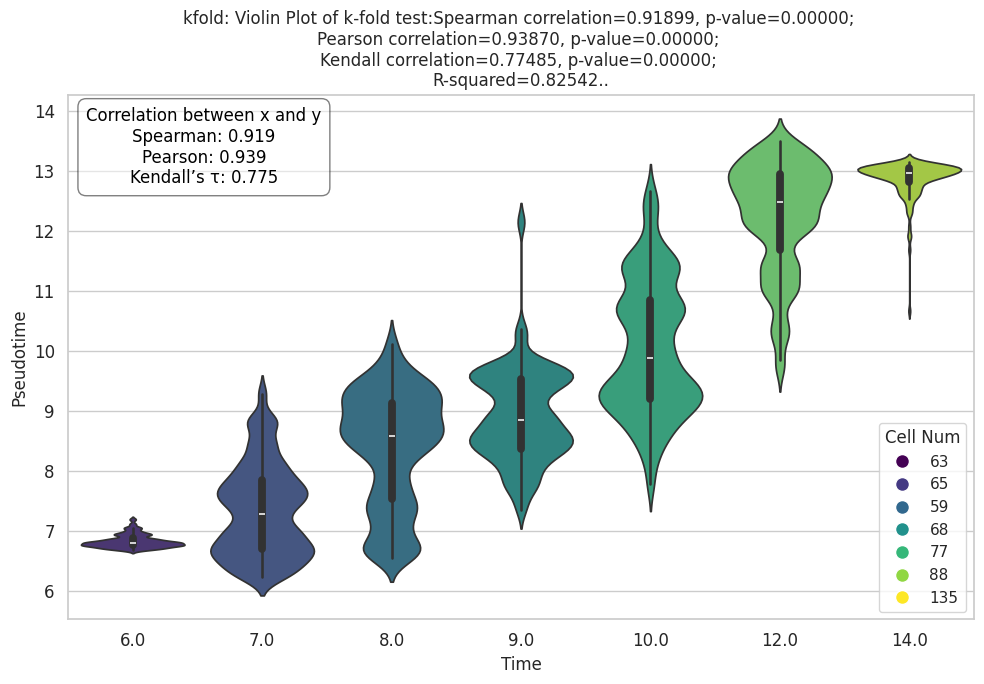

2025-07-13 09:37:58,660 INFO - __main__ - Finish plot image and fold-test. 
2025-07-13 09:37:58,661 INFO - __main__ - Finish fold-test. 


figure save as /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/results/Fig4_TemporalVAE_kFoldOn_humanEmbryo_xiang2019_250713/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/kfold_violine.png


In [20]:
predict_donors_dic, label_dic = task_kFoldTest(donor_list, sc_expression_df, donor_dic, batch_dic, special_path_str, cell_time, time_standard_type,
                                                       config, train_epoch_num, _logger, donor_str="day", batch_size=batch_size, cmap_color="viridis")

_logger.info("Finish fold-test.")